## 4.1 Segmentación de datos mediante técnicas avanzadas de clustering

### PASO 1. Cargar el dataset y seleccionar variables

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Cargar los datos
clientes = pd.read_csv("clientes.csv")

# Selección de variables numéricas relevantes
vars_cluster = ["edad", "ingreso_mensual",
                "frecuencia_compra_mensual",
                "ticket_promedio"]

X = clientes[vars_cluster]

# Escalamiento de los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Mostrar las primeras filas escaladas
pd.DataFrame(X_scaled, columns=vars_cluster).head()


,edad,ingreso_mensual,frecuencia_compra_mensual,ticket_promedio
0,0.470919,-0.859743,-1.176149,-0.447152
1,-0.145928,-1.597007,-1.127903,-1.059497
2,0.647161,-1.752150,-0.018237,-1.168790
3,1.616493,0.512295,-1.031410,-0.010318
4,-0.234050,-1.462948,-0.404208,-1.116793


### PASO 2. Aplicar K-Means (determinando un valor inicial de k)

In [ ]:
from sklearn.cluster import KMeans

# Modelo preliminar con 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X_scaled)

# Etiquetas asignadas
clientes["cluster_kmeans"] = kmeans.labels_

clientes.head()


,customer_id,edad,sexo,ingreso_mensual,ciudad,estado,canal_preferido,frecuencia_compra_mensual,ticket_promedio,categoria_favorita,cluster_kmeans
0,C0001,45,M,12365.250476,Tijuana,Baja California,web,0.5,677.31,Hogar,3
1,C0002,38,M,6732.309629,Querétaro,Querétaro,web,0.6,443.90,Computación,2
2,C0003,47,M,5546.966612,Querétaro,Querétaro,web,2.9,402.24,Computación,3
3,C0004,58,H,22848.079611,Mérida,Yucatán,web,0.8,843.82,Limpieza,3
4,C0005,37,M,7756.565180,Querétaro,Querétaro,app,2.1,422.06,Computación,2


### PASO 3. Visualización inicial con PCA (solo 2 componentes)

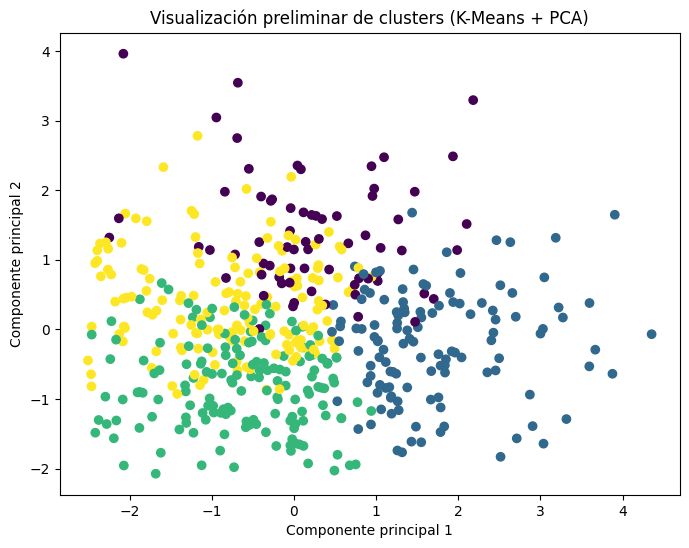

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clientes["cluster_kmeans"], cmap="viridis")
plt.title("Visualización preliminar de clusters (K-Means + PCA)")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.show()


### PASO 4: Determinar el número óptimo de clusters

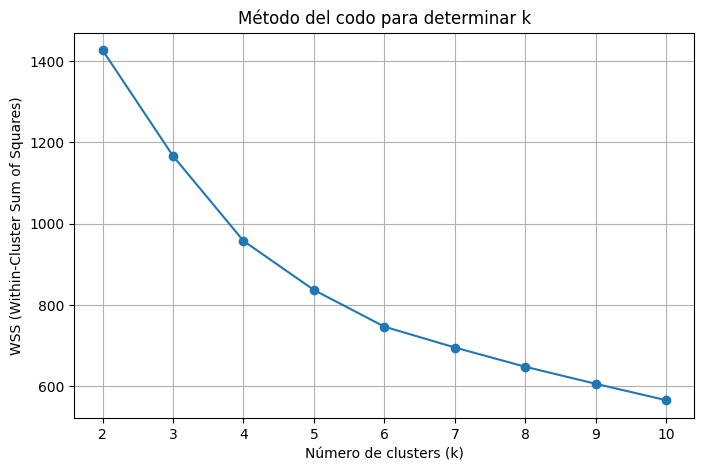

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wss = []  # Within-Cluster Sum of Squares

# Probar valores de k de 2 a 10
K = range(2, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wss.append(kmeans.inertia_)

# Gráfica del método del codo
plt.figure(figsize=(8,5))
plt.plot(K, wss, marker='o')
plt.title("Método del codo para determinar k")
plt.xlabel("Número de clusters (k)")
plt.ylabel("WSS (Within-Cluster Sum of Squares)")
plt.grid(True)
plt.show()


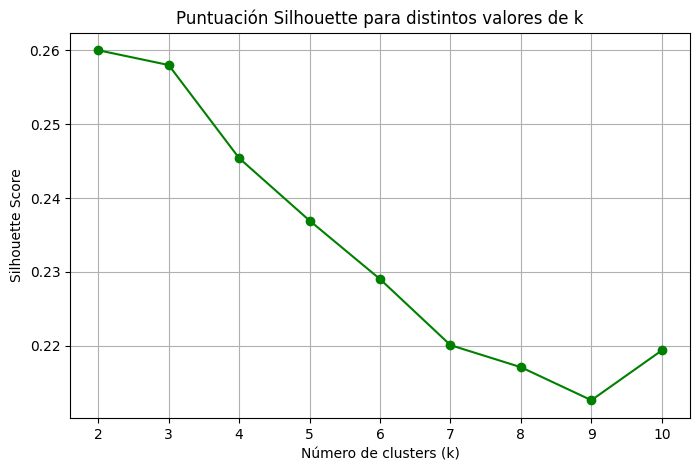

In [ ]:
## Código del método silhouette
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42).fit(X_scaled)
    score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(score)

# Gráfica de silhouette
plt.figure(figsize=(8,5))
plt.plot(K, silhouette_scores, marker='o', color='green')
plt.title("Puntuación Silhouette para distintos valores de k")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()


### PASO 5. Aplicar K-Means final con k = 4 y analizar cada cluster

In [ ]:
# Modelo final de K-Means con k=4
k_optimo = 4
kmeans_final = KMeans(n_clusters=k_optimo, random_state=42)
kmeans_final.fit(X_scaled)

# Agregar etiquetas finales al DataFrame
clientes["cluster_final"] = kmeans_final.labels_

# Obtener los centroides (en la escala original)
centroides = pd.DataFrame(
    scaler.inverse_transform(kmeans_final.cluster_centers_),
    columns=vars_cluster
)


### PASO 6. Crear una tabla comparativa por cluster

In [ ]:
# Resumen estadístico por cluster
resumen_clusters = clientes.groupby("cluster_final")[vars_cluster].mean().round(2)
resumen_clusters["n_clientes"] = clientes["cluster_final"].value_counts()

resumen_clusters


,edad,ingreso_mensual,frecuencia_compra_mensual,ticket_promedio,n_clientes
cluster_final,,,,,
0,40.77,20567.69,6.70,861.47,69
1,39.39,27598.42,2.39,1342.48,122
2,29.38,15448.26,2.43,663.91,156
3,49.84,14842.35,2.19,634.52,153


### PASO 7. Visualización final de clusters con PCA (K-Means final)

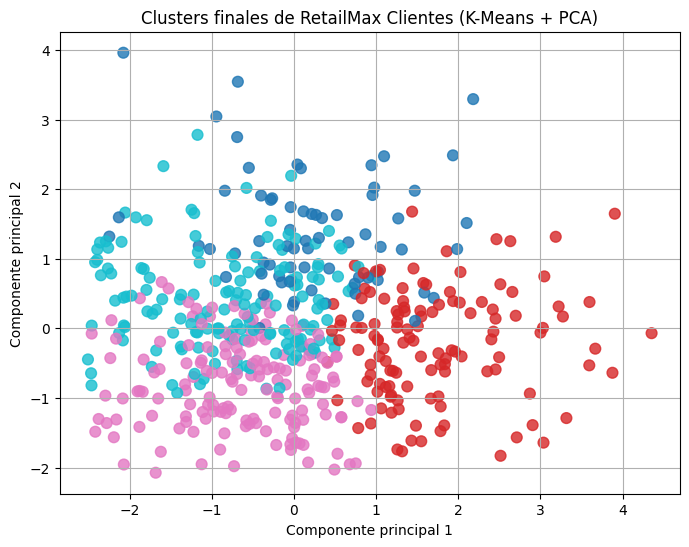

In [ ]:
# Aplicar PCA a los datos escalados
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Gráfica final de clusters
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1],
            c=clientes["cluster_final"],
            cmap="tab10", s=60, alpha=0.8)

plt.title("Clusters finales de RetailMax Clientes (K-Means + PCA)")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.grid(True)
plt.show()



### PASO 8. Clustering jerárquico aglomerativo y dendrograma


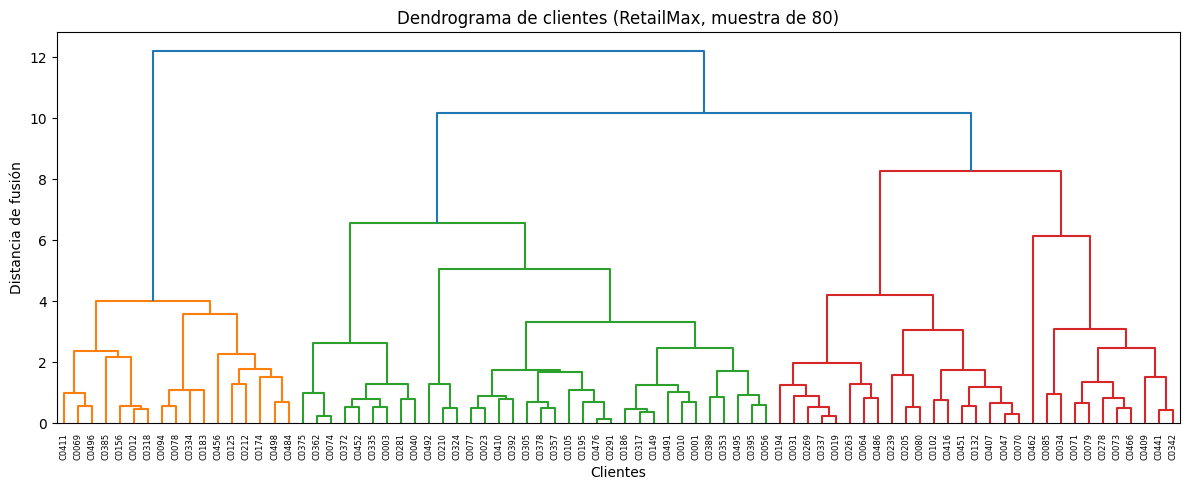

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# Para el dendrograma no conviene usar los 500 clientes completos.
# Tomamos una muestra de 80 clientes para visualizarlo de forma clara.
muestra = clientes.sample(80, random_state=42)
X_muestra = muestra[vars_cluster]

# Reutilizamos el escalador para mantener la misma escala
X_muestra_scaled = scaler.transform(X_muestra)

# Cálculo del enlace jerárquico (método 'ward')
Z = linkage(X_muestra_scaled, method="ward")

plt.figure(figsize=(12, 5))
dendrogram(Z, labels=muestra["customer_id"].values, leaf_rotation=90)
plt.title("Dendrograma de clientes (RetailMax, muestra de 80)")
plt.xlabel("Clientes")
plt.ylabel("Distancia de fusión")
plt.tight_layout()
plt.show()


### PASO 9. Asignar clusters jerárquicos y compararlos

In [ ]:
from sklearn.cluster import AgglomerativeClustering

# Modelo jerárquico aglomerativo con 4 clusters
agg = AgglomerativeClustering(
    n_clusters=4,
    metric="euclidean",   # antes: affinity="euclidean"
    linkage="ward"
)

# Ajuste del modelo y asignación de clusters
clientes["cluster_jerarquico"] = agg.fit_predict(X_scaled)

# Resumen comparativo de clusters jerárquicos
resumen_jerarquico = (
    clientes
    .groupby("cluster_jerarquico")[vars_cluster]
    .mean()
    .round(2)
)

# Contar clientes por cluster y alinear con el índice del resumen
resumen_jerarquico["n_clientes"] = (
    clientes["cluster_jerarquico"]
    .value_counts()
    .reindex(resumen_jerarquico.index)
)

resumen_jerarquico






,edad,ingreso_mensual,frecuencia_compra_mensual,ticket_promedio,n_clientes
cluster_jerarquico,,,,,
0,39.21,18243.13,1.78,759.24,210
1,41.53,21180.88,5.99,899.60,100
2,39.35,26648.44,2.31,1335.49,105
3,38.92,8467.70,2.97,402.93,85


### PASO 10. Aplicar DBSCAN para identificar grupos y detectar clientes “ruido” (outliers)

In [ ]:
# PASO 10.1 — Contar clusters y outliers

from sklearn.cluster import DBSCAN
import numpy as np

# DBSCAN con valores iniciales (pueden ajustarse según resultados)
dbscan = DBSCAN(eps=0.7, min_samples=10)
dbscan.fit(X_scaled)

# Agregar etiquetas al dataset
clientes["cluster_dbscan"] = dbscan.labels_

# Valores únicos encontrados
np.unique(dbscan.labels_)


array([-1,  0])

In [ ]:
#### PASO 10.2 — Contar clusters y outliers

clientes["cluster_dbscan"].value_counts()


,count
cluster_dbscan,
0,264
-1,236


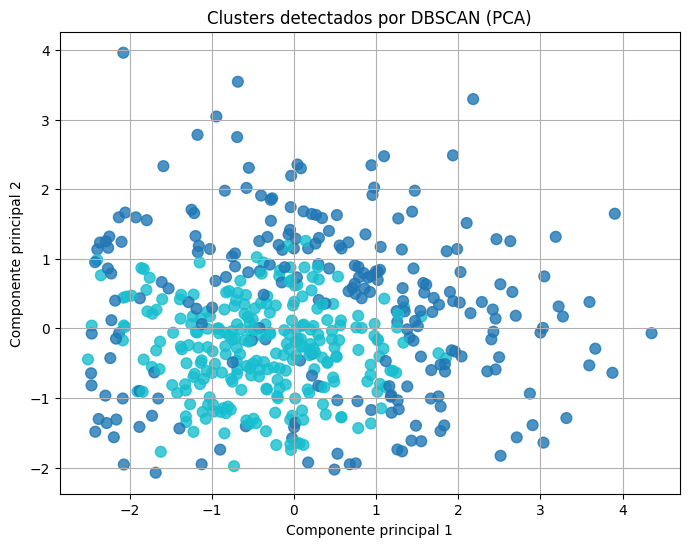

In [ ]:
# PASO 10.3 — Visualización del clustering con PCA
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1],
            c=clientes["cluster_dbscan"],
            cmap="tab10", s=60, alpha=0.8)

plt.title("Clusters detectados por DBSCAN (PCA)")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.grid(True)
plt.show()


In [ ]:
# PASO 10.4 — Identificar outliers y analizar su perfil
clientes_outliers = clientes[clientes["cluster_dbscan"] == -1]
clientes_outliers.describe().round(2)


,edad,ingreso_mensual,frecuencia_compra_mensual,ticket_promedio,cluster_kmeans,cluster_final,cluster_jerarquico,cluster_dbscan
count,236.00,236.00,236.00,236.00,236.00,236.00,236.00,236.0
mean,40.85,21184.50,3.70,961.57,1.34,1.34,1.54,-1.0
std,13.91,9080.44,2.53,463.43,1.05,1.05,0.97,0.0
min,18.00,5000.00,0.10,205.73,0.00,0.00,0.00,-1.0
25%,30.00,14783.74,1.58,592.18,1.00,1.00,1.00,-1.0
50%,41.50,22410.17,3.30,959.50,1.00,1.00,2.00,-1.0
75%,51.00,27681.79,5.52,1252.14,2.00,2.00,2.00,-1.0
max,70.00,39059.06,14.40,2209.77,3.00,3.00,3.00,-1.0
